# 02 - Exploratory Data Analysis (EDA)

Exploratory analysis of numerical and categorical features, relationships among variables, and accident-severity distribution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/victorian_road_crash_data.csv"
df = pd.read_csv(DATA_PATH)
target_col = "SEVERITY"

severity_labels = {
    1: "Fatal",
    2: "Serious Injury",
    3: "Other Injury",
    4: "Non Injury"
}

print(f"Dataset shape: {df.shape}")

Dataset shape: (200352, 52)


## Numerical vs Categorical Features

In [2]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)
print(f"\nTotal numerical features: {len(numerical_features)}")

print("\nCategorical Features:")
print(categorical_features)
print(f"\nTotal categorical features: {len(categorical_features)}")

Numerical Features:
['DCA_CODE', 'ROAD_ROUTE_1', 'LATITUDE', 'LONGITUDE', 'VICGRID_X', 'VICGRID_Y', 'TOTAL_PERSONS', 'INJ_OR_FATAL', 'FATALITY', 'SERIOUSINJURY', 'OTHERINJURY', 'NONINJURED', 'MALES', 'FEMALES', 'BICYCLIST', 'PASSENGER', 'DRIVER', 'PEDESTRIAN', 'PILLION', 'MOTORCYCLIST', 'UNKNOWN', 'PED_CYCLIST_5_12', 'PED_CYCLIST_13_18', 'OLD_PED_65_AND_OVER', 'OLD_DRIVER_75_AND_OVER', 'YOUNG_DRIVER_18_25', 'NO_OF_VEHICLES', 'HEAVYVEHICLE', 'PASSENGERVEHICLE', 'MOTORCYCLE', 'PT_VEHICLE']

Total numerical features: 31

Categorical Features:
['ACCIDENT_NO', 'ACCIDENT_DATE', 'ACCIDENT_TIME', 'ACCIDENT_TYPE', 'DAY_OF_WEEK', 'DCA_CODE_DESCRIPTION', 'LIGHT_CONDITION', 'POLICE_ATTEND', 'ROAD_GEOMETRY', 'SEVERITY', 'SPEED_ZONE', 'RUN_OFFROAD', 'ROAD_NAME', 'ROAD_TYPE', 'LGA_NAME', 'DTP_REGION', 'DEG_URBAN_NAME', 'SRNS', 'RMA', 'DIVIDED', 'STAT_DIV_NAME']

Total categorical features: 21


## Correlation Matrix

Correlation is examined for numerical variables to identify potentially related features before model development. The target is excluded here when it is numeric so that the feature-feature relationships can be inspected independently.

In [3]:
numerical_cols = [col for col in numerical_features if col != target_col]
corr_matrix = df[numerical_cols].corr(numeric_only=True)
print("--- Correlation Matrix ---")
display(corr_matrix)

--- Correlation Matrix ---


,DCA_CODE,ROAD_ROUTE_1,LATITUDE,LONGITUDE,VICGRID_X,VICGRID_Y,TOTAL_PERSONS,INJ_OR_FATAL,FATALITY,SERIOUSINJURY,...,PED_CYCLIST_5_12,PED_CYCLIST_13_18,OLD_PED_65_AND_OVER,OLD_DRIVER_75_AND_OVER,YOUNG_DRIVER_18_25,NO_OF_VEHICLES,HEAVYVEHICLE,PASSENGERVEHICLE,MOTORCYCLE,PT_VEHICLE
DCA_CODE,1.000000,0.104577,0.095470,0.037382,0.037238,0.093573,-0.345196,-0.098903,0.019548,0.035645,...,-0.071368,-0.092359,-0.164511,-0.069131,-0.086618,-0.358098,-0.017036,-0.366120,0.239385,-0.021450
ROAD_ROUTE_1,0.104577,1.000000,0.036592,-0.007961,-0.007972,0.036687,-0.151901,-0.083506,-0.019426,-0.028222,...,0.056532,0.039874,0.039274,-0.008034,-0.078925,-0.186156,-0.118256,-0.192390,0.077541,0.000374
LATITUDE,0.095470,0.036592,1.000000,-0.171361,-0.178016,0.999915,-0.045264,0.017800,0.046087,-0.002349,...,-0.003299,-0.007647,-0.007835,0.008276,-0.018720,-0.099094,0.025016,-0.086561,0.033513,-0.011532
LONGITUDE,0.037382,-0.007961,-0.171361,1.000000,0.999874,-0.169183,-0.019564,-0.025379,-0.015042,-0.024787,...,-0.002538,-0.006039,-0.004947,-0.007899,-0.014784,-0.011433,-0.032586,-0.022757,0.072502,-0.000816
VICGRID_X,0.037238,-0.007972,-0.178016,0.999874,1.000000,-0.175820,-0.019447,-0.025384,-0.015108,-0.024321,...,-0.002486,-0.005993,-0.004948,-0.008025,-0.014732,-0.011190,-0.032518,-0.022661,0.072405,-0.000716
VICGRID_Y,0.093573,0.036687,0.999915,-0.169183,-0.175820,1.000000,-0.044589,0.017364,0.045524,-0.002741,...,-0.003222,-0.007578,-0.007734,0.008103,-0.018487,-0.097418,0.024641,-0.085135,0.032869,-0.011279
TOTAL_PERSONS,-0.345196,-0.151901,-0.045264,-0.019564,-0.019447,-0.044589,1.000000,0.532201,0.023896,0.120483,...,0.007692,-0.006140,-0.010765,0.033462,0.169316,0.533847,0.047753,0.494752,-0.184233,0.114265
INJ_OR_FATAL,-0.098903,-0.083506,0.017800,-0.025379,-0.025384,0.017364,0.532201,1.000000,0.124108,0.360470,...,-0.009627,-0.027417,-0.025985,0.032525,0.090007,0.179370,0.014516,0.226024,-0.115678,0.035664
FATALITY,0.019548,-0.019426,0.046087,-0.015042,-0.015108,0.045524,0.023896,0.124108,1.000000,0.020501,...,-0.001360,-0.006614,0.043342,0.021564,-0.015861,-0.031546,0.065006,-0.039592,0.015801,0.007278
SERIOUSINJURY,0.035645,-0.028222,-0.002349,-0.024787,-0.024321,-0.002741,0.120483,0.360470,0.020501,1.000000,...,-0.006513,-0.012623,0.040291,0.060706,-0.011944,-0.029379,0.017404,-0.025260,0.047641,0.009654


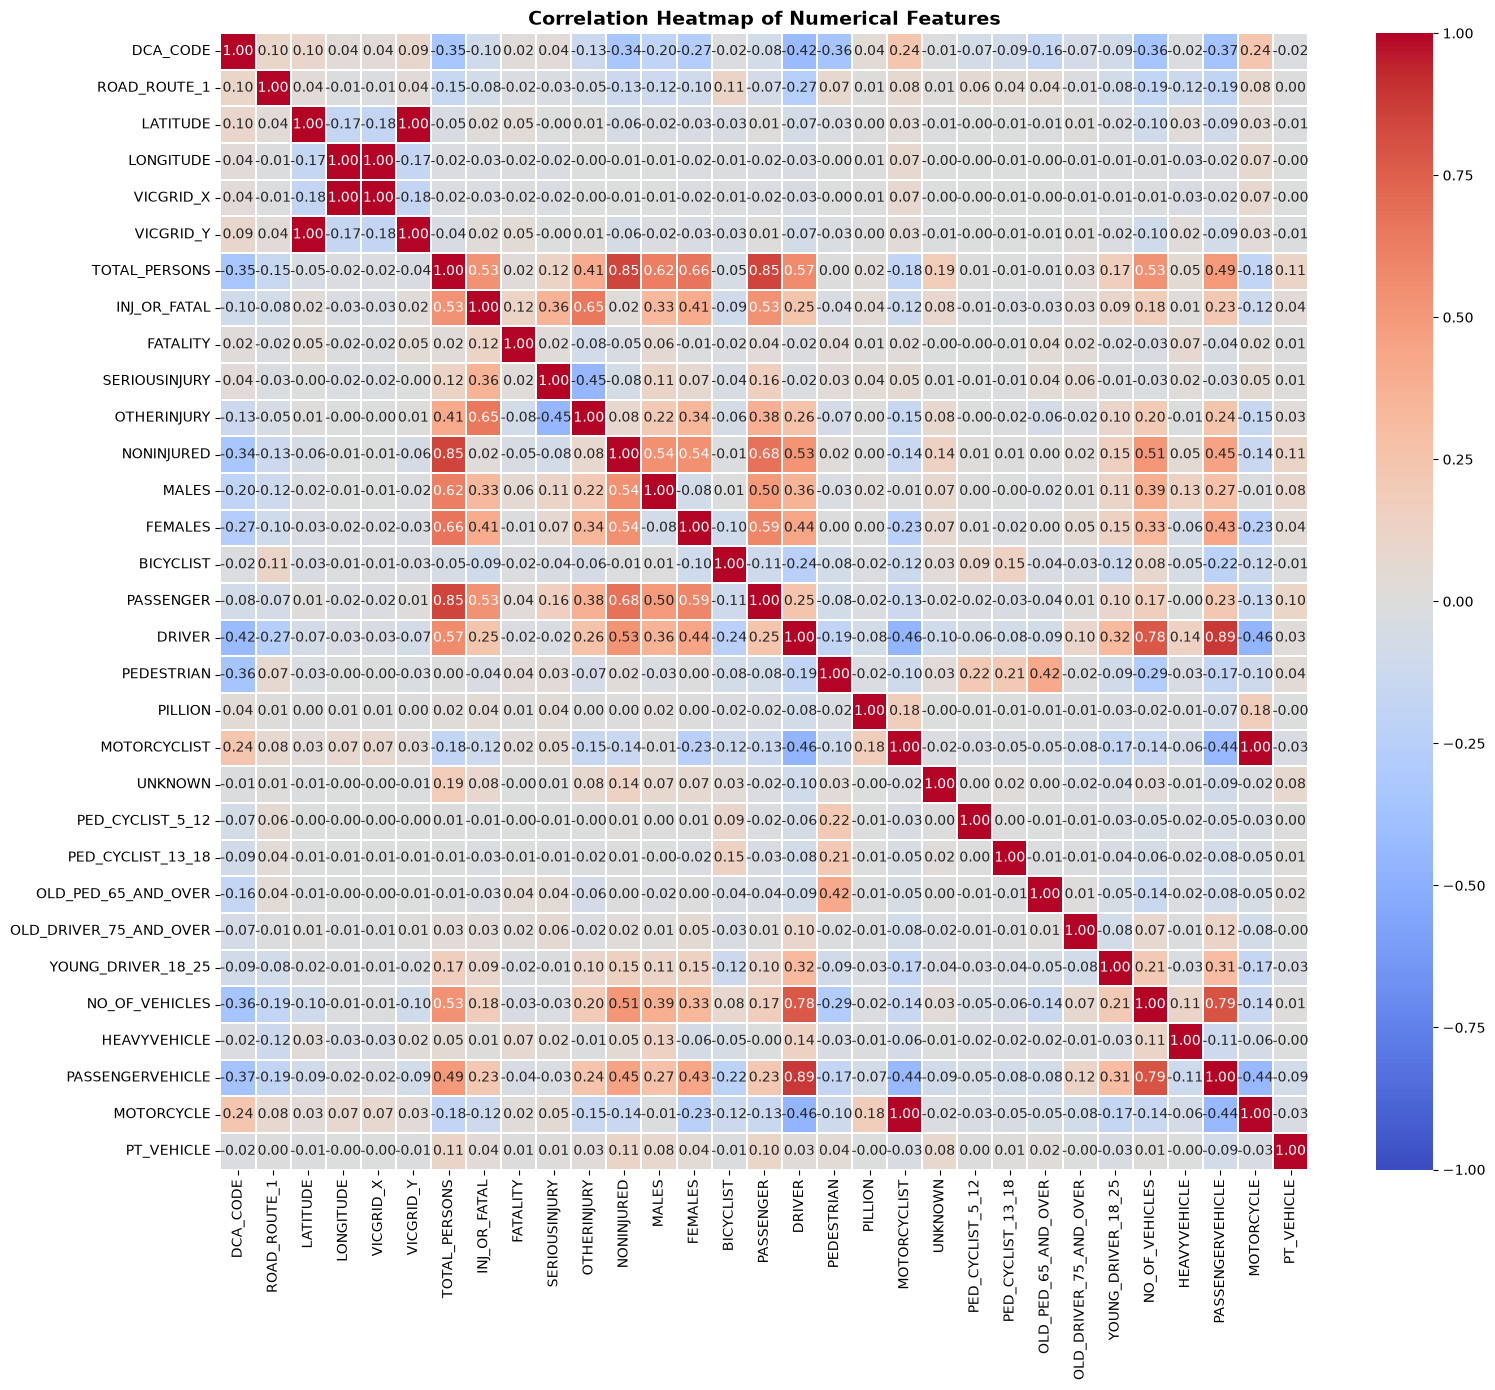

In [4]:
plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.3
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Accident Severity Distribution

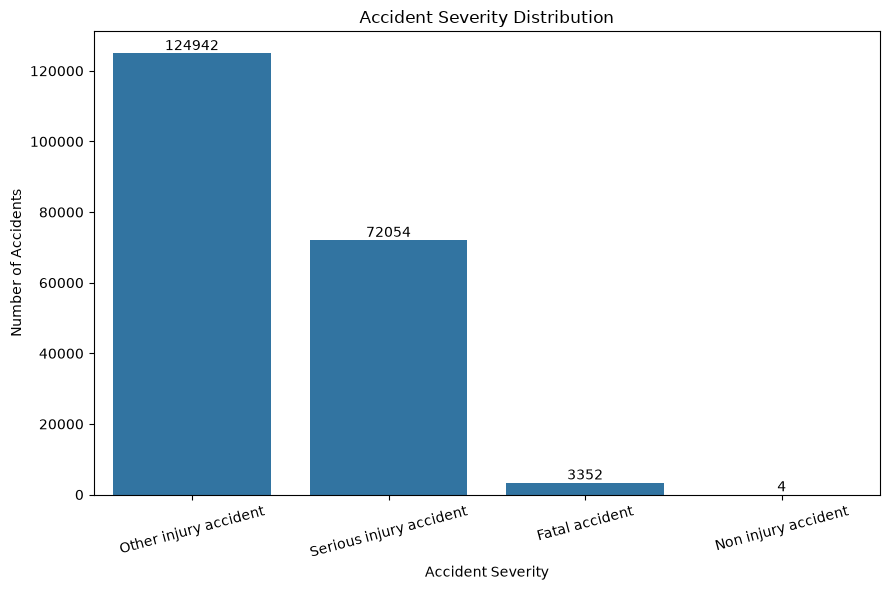

In [5]:
severity_counts = df[target_col].map(severity_labels).fillna(df[target_col].astype(str)).value_counts()

plt.figure(figsize=(9, 6))
ax = sns.countplot(
    data=pd.DataFrame({"Severity": df[target_col].map(severity_labels).fillna(df[target_col].astype(str))}),
    x="Severity",
    order=severity_counts.index
)
plt.title("Accident Severity Distribution")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

## Numerical Feature Distributions

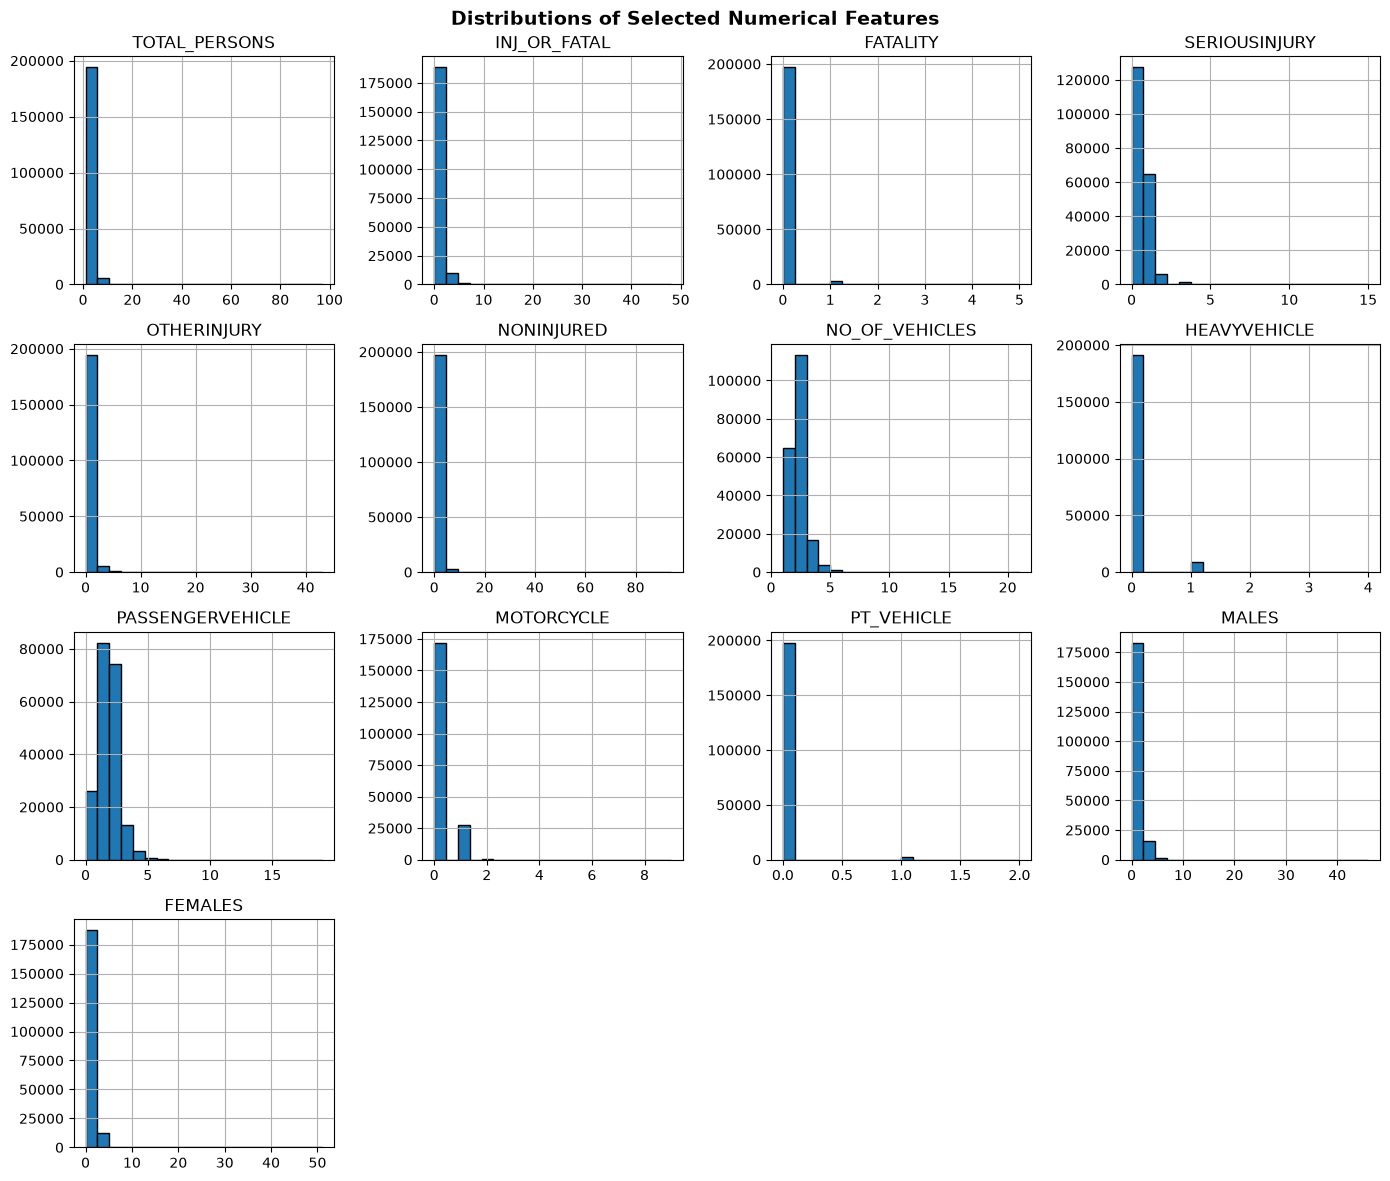

In [6]:
# Select a manageable set of meaningful numerical variables for visual inspection.
preferred_numeric = [
    "TOTAL_PERSONS", "INJ_OR_FATAL", "FATALITY", "SERIOUSINJURY",
    "OTHERINJURY", "NONINJURED", "NO_OF_VEHICLES", "HEAVYVEHICLE",
    "PASSENGERVEHICLE", "MOTORCYCLE", "PT_VEHICLE", "MALES", "FEMALES"
]
plot_numeric = [col for col in preferred_numeric if col in df.columns]

df[plot_numeric].hist(figsize=(14, 12), bins=20, edgecolor="black")
plt.suptitle("Distributions of Selected Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Boxplots for Selected Numerical Features

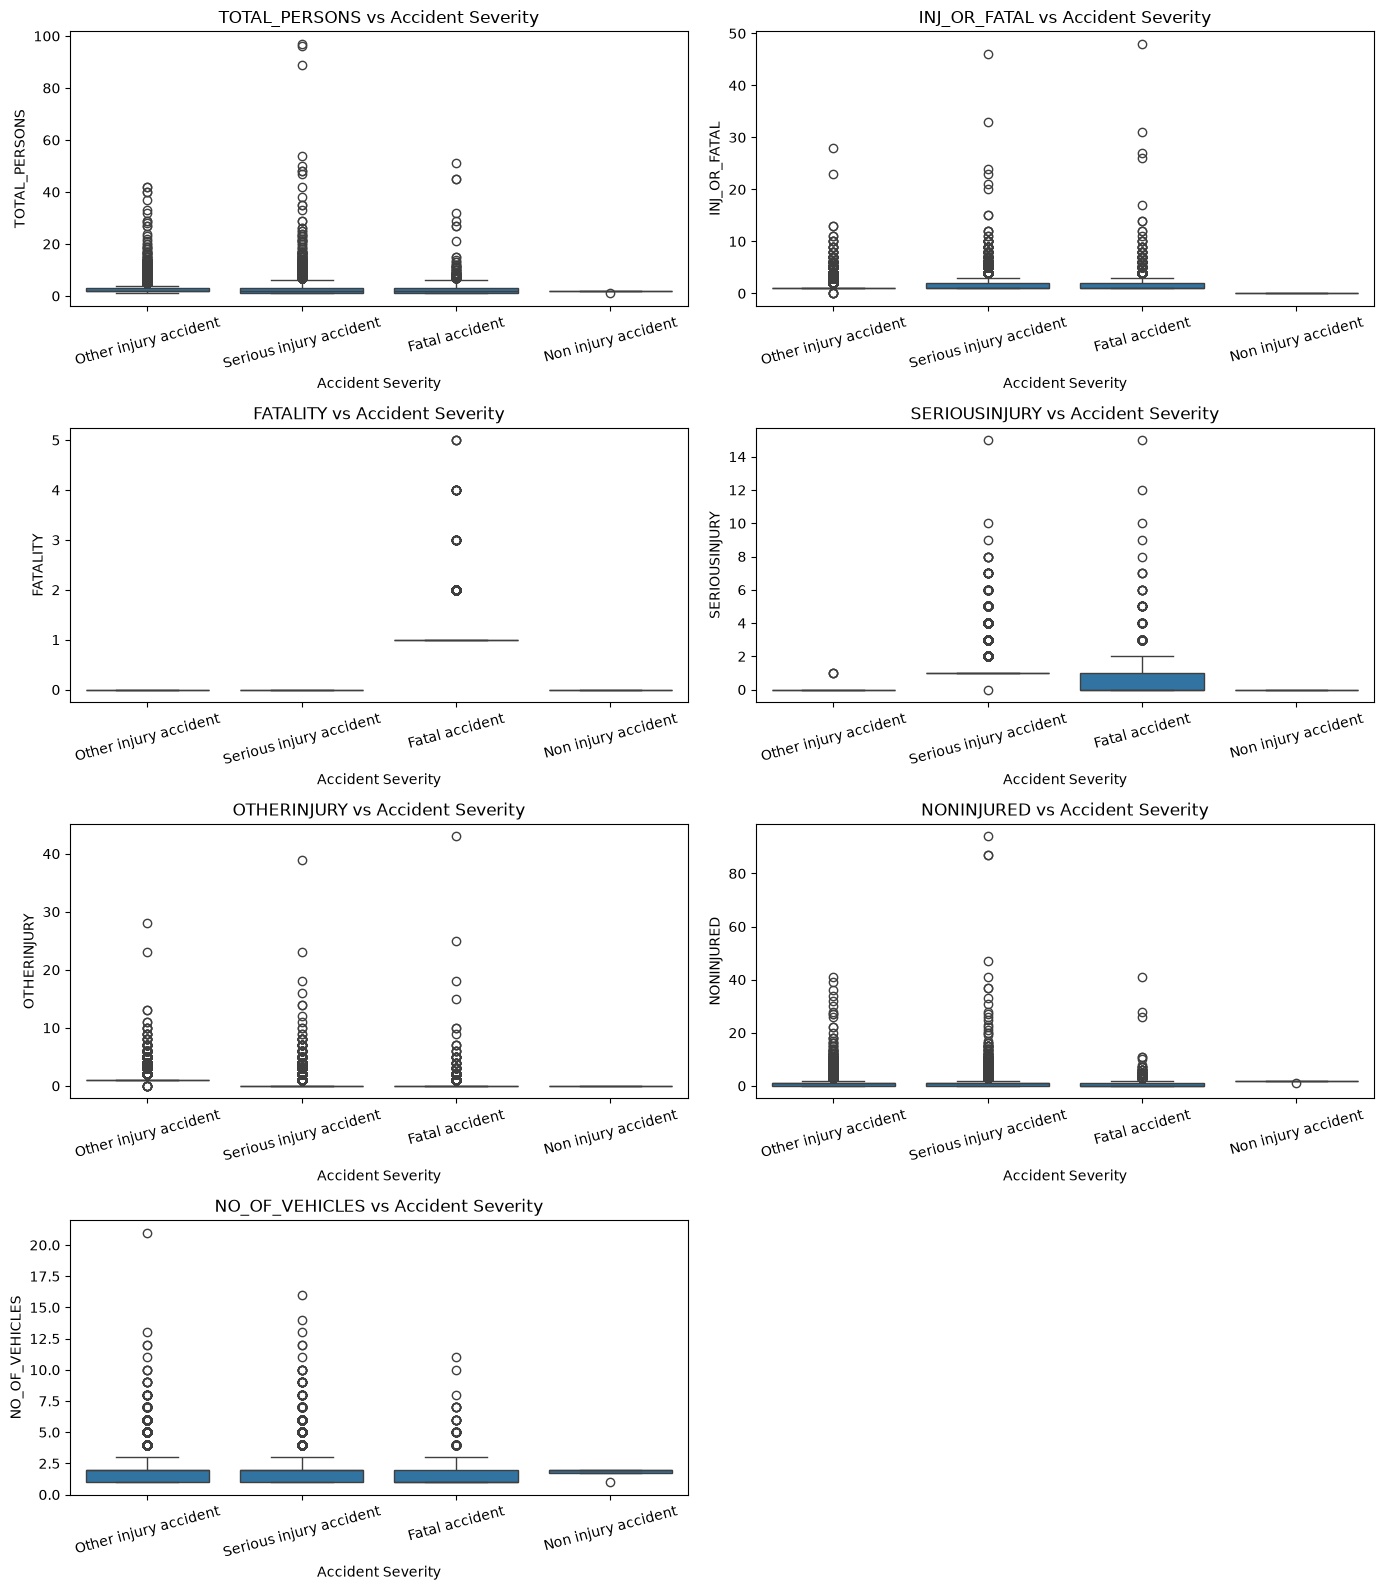

In [7]:
boxplot_features = [
    "TOTAL_PERSONS", "INJ_OR_FATAL", "FATALITY", "SERIOUSINJURY",
    "OTHERINJURY", "NONINJURED", "NO_OF_VEHICLES"
]
boxplot_features = [col for col in boxplot_features if col in df.columns]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

severity_plot = df[target_col].map(severity_labels).fillna(df[target_col].astype(str))

for i, col in enumerate(boxplot_features):
    sns.boxplot(x=severity_plot, y=df[col], ax=axes[i])
    axes[i].set_title(f"{col} vs Accident Severity")
    axes[i].set_xlabel("Accident Severity")
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis="x", rotation=15)

for i in range(len(boxplot_features), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Categorical Feature Analysis

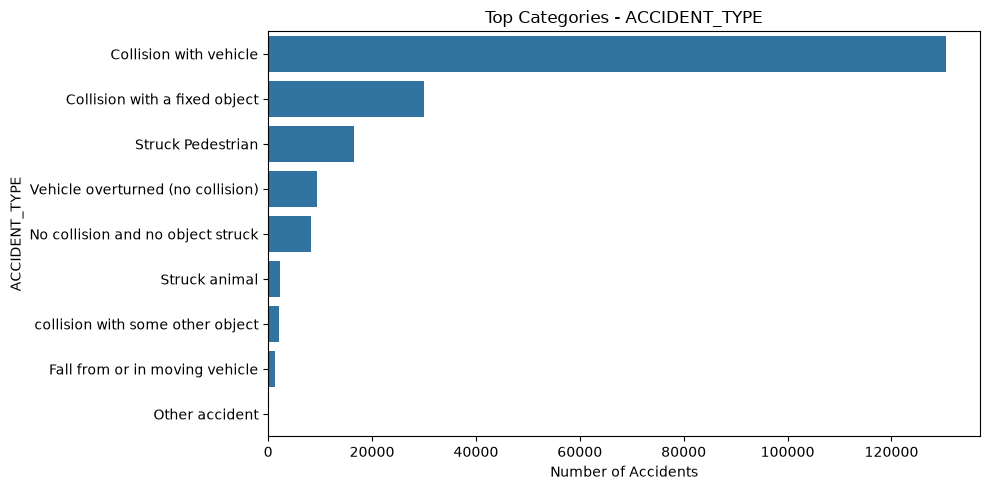

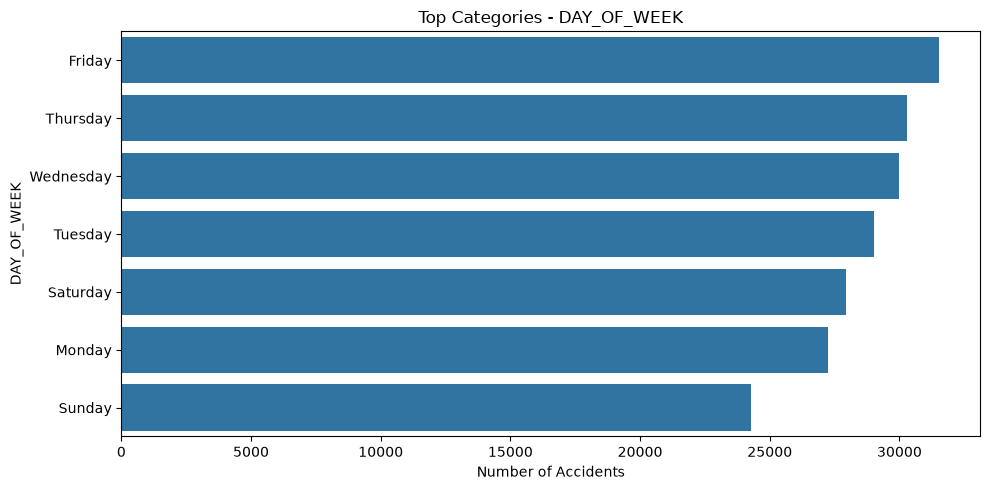

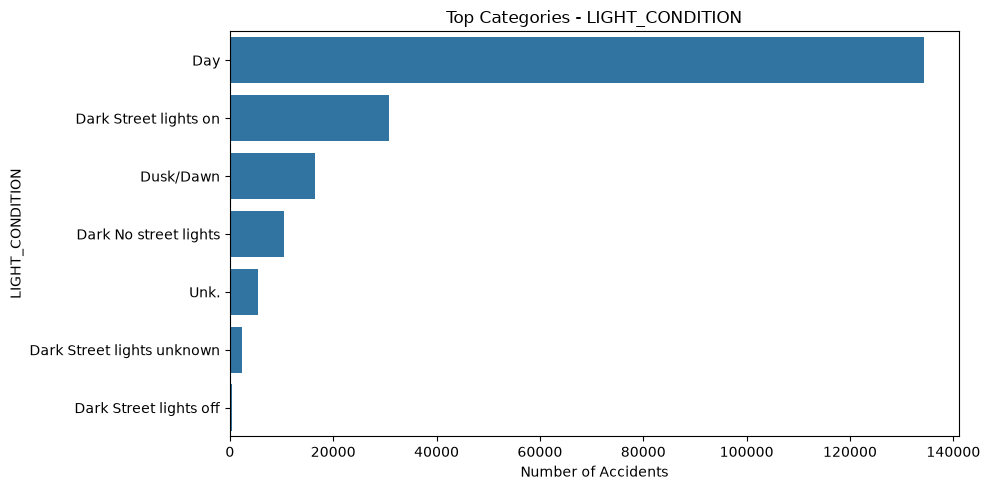

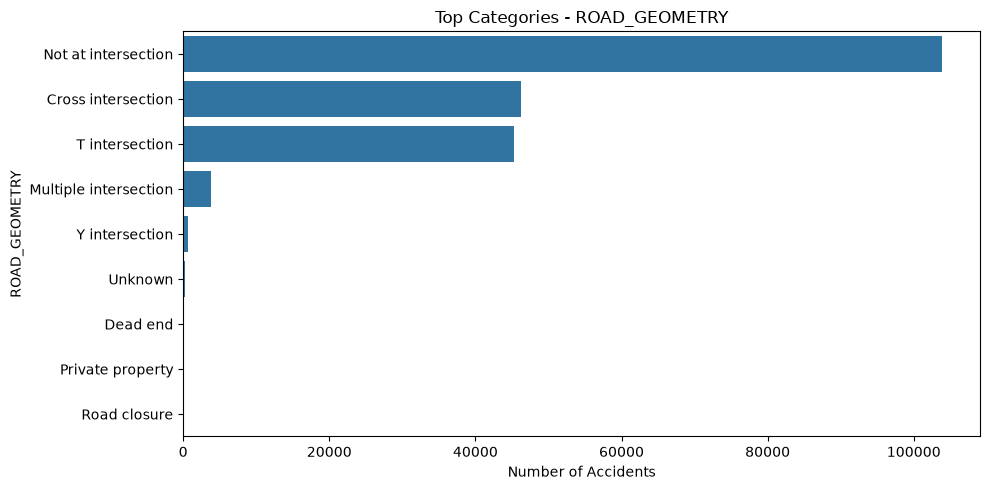

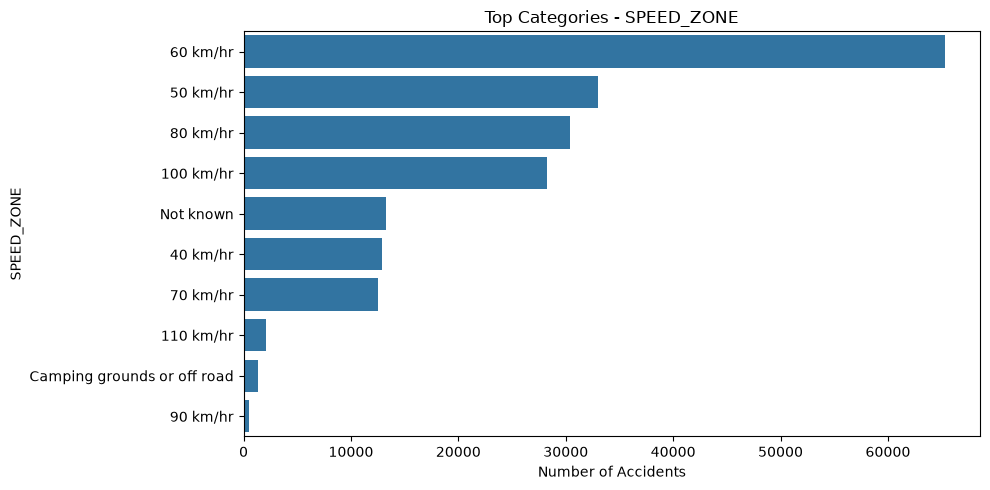

TypeError: 'value' must be an instance of str or bytes, not a float

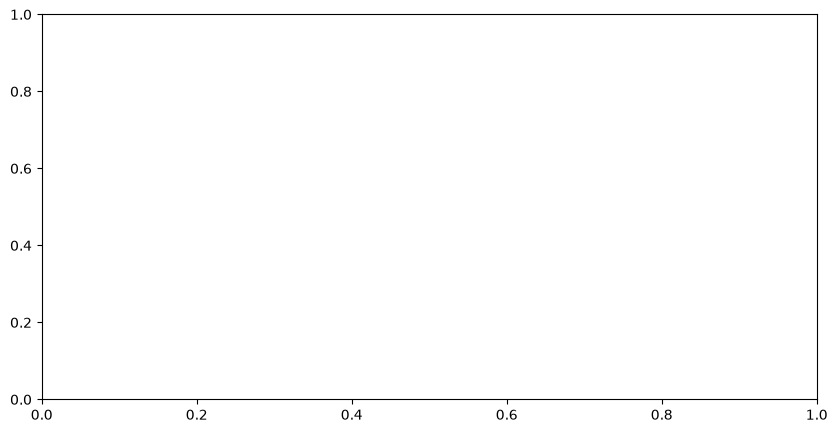

In [ ]:
for col in categorical_to_plot:
    plt.figure(figsize=(10, 5))

    plot_data = df[[col]].copy()
    plot_data[col] = plot_data[col].fillna("Missing").astype(str)

    order = plot_data[col].value_counts().head(10).index

    sns.countplot(
        data=plot_data,
        y=col,
        order=order
    )

    plt.title(f"Top Categories - {col}")
    plt.xlabel("Number of Accidents")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Important Data-Leakage Check

Several columns in this dataset describe injuries or fatalities after the crash occurred (for example `FATALITY`, `SERIOUSINJURY`, and `OTHERINJURY`). Because the target is `SEVERITY`, these variables must be reviewed carefully and are expected to be excluded from model features if they directly reveal the outcome. This decision will be finalized during preprocessing.

In [9]:
potential_leakage = [
    "INJ_OR_FATAL", "FATALITY", "SERIOUSINJURY", "OTHERINJURY", "NONINJURED"
]
print("Potential target-leakage columns to review:")
print([col for col in potential_leakage if col in df.columns])

Potential target-leakage columns to review:
['INJ_OR_FATAL', 'FATALITY', 'SERIOUSINJURY', 'OTHERINJURY', 'NONINJURED']
